# Notebook 07_LabelEfficiency — Label-Efficiency Experiment (Fixed)

**Mục đích:** Chạy lại label-efficiency với config đúng cho I-JEPA.

**Cải tiến so với NB05:**
- Dùng **2 I-JEPA models**: Partial FT v1 + Full FT v2
- **`enc_lr` fix**: `3e-6` (phù hợp với training config gốc, thay vì `1e-5` quá cao)
- **Epoch tăng**: 10 → 15 (đủ để encoder adapt)
- **`head_lr` giảm**: `3e-5` (tránh head overfit nhanh khi enc_lr nhỏ)
- ResNet50 giữ nguyên làm baseline so sánh
- `torch.amp` thay `torch.cuda.amp`
- Gradient flush cuối epoch đúng


In [1]:
# ============================================================
# CELL 1: IMPORTS VÀ CẤU HÌNH
# ============================================================
import gc, json, time, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

try:
    import timm
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","timm"])
    import timm

try:
    import pydicom
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","pydicom"])
    import pydicom

SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

INPUT_ROOT   = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
OUTPUT_DIR   = Path("/kaggle/working/notebook07_label_efficiency")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

NOTEBOOK_START = time.time()
SESSION_LIMIT  = 11.0 * 3600  # 11h safe limit
print("Output:", OUTPUT_DIR)


Device: cuda
GPU: Tesla T4
GPU count: 2
Output: /kaggle/working/notebook07_label_efficiency


In [2]:
# ============================================================
# CELL 2: TÌM INPUT FILES
# ============================================================
def find_file(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None

RSNA_TRAIN_CSV = find_file("rsna_train.csv")
RSNA_VAL_CSV   = find_file("rsna_val.csv")
RSNA_TEST_CSV  = find_file("rsna_test.csv")

IJEPA_PARTIAL_V1_CKPT = find_file("ijepa_partial_finetune_best.pth")
IJEPA_FULL_V2_CKPT    = find_file("ijepa_full_finetune_v2_best.pth")

print("RSNA Train:", RSNA_TRAIN_CSV)
print("RSNA Val  :", RSNA_VAL_CSV)
print("RSNA Test :", RSNA_TEST_CSV)
print()
print("I-JEPA Partial FT v1:", IJEPA_PARTIAL_V1_CKPT)
print("I-JEPA Full FT v2   :", IJEPA_FULL_V2_CKPT)

assert RSNA_TRAIN_CSV, "Thiếu rsna_train.csv"
assert RSNA_VAL_CSV,   "Thiếu rsna_val.csv"
assert RSNA_TEST_CSV,  "Thiếu rsna_test.csv"
assert IJEPA_PARTIAL_V1_CKPT or IJEPA_FULL_V2_CKPT, \
    "Thiếu tất cả I-JEPA checkpoints"


RSNA Train: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_train.csv
RSNA Val  : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_val.csv
RSNA Test : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv

I-JEPA Partial FT v1: /kaggle/input/notebooks/nguyentongphuc/04-fine-tune-i-jepa-2/notebook04_ijepa_finetune/checkpoints/ijepa_partial_finetune_best.pth
I-JEPA Full FT v2   : /kaggle/input/notebooks/trnhuti666/04-fine-tune-i-jepa-4/notebook04_ijepa_finetune_v2/checkpoints/ijepa_full_finetune_v2_best.pth


In [3]:
# ============================================================
# CELL 3: DATASET + TRANSFORMS
# ============================================================
def fix_df_paths(df):
    def _fix(p):
        if Path(str(p)).exists(): return p
        matches = list(INPUT_ROOT.rglob(Path(str(p)).name))
        return str(matches[0]) if matches else None
    df = df.copy()
    df["image_path"] = df["image_path"].apply(_fix)
    return df.dropna(subset=["image_path"]).reset_index(drop=True)

def read_image(path):
    p = str(path)
    if p.endswith(".dcm") or p.endswith(".dicom"):
        ds  = pydicom.dcmread(p)
        arr = ds.pixel_array.astype(np.float32)
        photometric = getattr(ds, "PhotometricInterpretation", "MONOCHROME2")
        if str(photometric).strip().upper() == "MONOCHROME1":
            arr = arr.max() - arr
        mn, mx = arr.min(), arr.max()
        arr = ((arr - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
        return Image.fromarray(arr).convert("RGB")
    return Image.open(p).convert("RGB")

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(7),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class RSNADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_image(row["image_path"])
        if self.transform: img = self.transform(img)
        return img, torch.tensor(float(row["label"]), dtype=torch.float32)

print("Dataset helpers defined ✓")


Dataset helpers defined ✓


In [4]:
# ============================================================
# CELL 4: ĐỌC RSNA METADATA
# ============================================================
train_df = fix_df_paths(pd.read_csv(RSNA_TRAIN_CSV))
val_df   = fix_df_paths(pd.read_csv(RSNA_VAL_CSV))
test_df  = fix_df_paths(pd.read_csv(RSNA_TEST_CSV))

n_neg      = (train_df["label"] == 0).sum()
n_pos      = (train_df["label"] == 1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32)

print(f"Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print(f"POS_WEIGHT = {POS_WEIGHT.item():.4f}  (neg={n_neg}, pos={n_pos})")
print(f"Train label dist: {train_df['label'].value_counts().to_dict()}")

val_loader  = DataLoader(RSNADataset(val_df,  eval_transform),
                         batch_size=16, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(RSNADataset(test_df, eval_transform),
                         batch_size=16, shuffle=False,
                         num_workers=2, pin_memory=True)
print("Val/Test loaders ready ✓")


Train 18,678 | Val 4,003 | Test 4,003
POS_WEIGHT = 3.4387  (neg=14470, pos=4208)
Train label dist: {0: 14470, 1: 4208}
Val/Test loaders ready ✓


In [5]:
# ============================================================
# CELL 5: MODEL CLASS + LOAD HELPERS
# ============================================================
class IJEPAClassifier(nn.Module):
    def __init__(self, encoder, embed_dim=384, dropout=0.2):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )
    def forward(self, x):
        return self.classifier(self.encoder(x)).squeeze(1)

def load_ijepa_fresh(ckpt_path, dropout=0.2):
    """Load I-JEPA từ checkpoint, trả về model với ALL params requires_grad=True."""
    enc   = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=0)
    model = IJEPAClassifier(enc, embed_dim=enc.num_features, dropout=dropout)
    try:    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError: ck = torch.load(ckpt_path, map_location="cpu")
    sd = ck.get("model_state_dict", ck)
    missing, _ = model.load_state_dict(sd, strict=False)
    if missing: print(f"  Missing keys: {len(missing)}")
    # Unfreeze toàn bộ để fine-tune
    for p in model.parameters():
        p.requires_grad = True
    model = model.to(DEVICE)
    print(f"  Loaded: {Path(ckpt_path).name} | "
          f"epoch={ck.get('epoch','?')} | "
          f"best_auc={round(float(ck['best_auc']),4) if isinstance(ck.get('best_auc'),(int,float)) else '?'}")
    return model

@torch.no_grad()
def quick_auc(model, loader):
    model.eval()
    probs, lbls = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
            logits = model(imgs)
        logits = logits.squeeze(-1) if logits.dim() > 1 else logits
        probs.extend(torch.sigmoid(logits).cpu().numpy())
        lbls.extend(labels.numpy())
    return roc_auc_score(np.array(lbls).astype(int), np.array(probs))

print("Model helpers defined ✓")


Model helpers defined ✓


In [6]:
# ============================================================
# CELL 6: train_quick() — FIXED CONFIG
# ============================================================
# FIX so với NB05:
#   - enc_lr: 1e-5 → 3e-6 (phù hợp với v2 training config)
#   - head_lr: 1e-4 → 3e-5 (tránh head overfit nhanh)
#   - epochs: 10 → 15 (đủ để encoder adapt với lr nhỏ)
#   - torch.amp thay torch.cuda.amp
#   - gradient flush cuối epoch
#   - Hỗ trợ cả IJEPAClassifier lẫn ResNet50
# ============================================================

# ── Config label-efficiency ──────────────────────────────
LABEL_FRACTIONS = [0.10, 0.25, 0.50, 1.00]
LE_SEED         = 42
LE_EPOCHS       = 15       # FIX: tăng từ 10
MAX_LE_HOURS    = 9.0      # safe limit

# ── I-JEPA fine-tune configs ─────────────────────────────
IJEPA_HEAD_LR   = 3e-5    # FIX: giảm từ 1e-4
IJEPA_ENC_LR    = 3e-6    # FIX: thay 1e-5, phù hợp v2 config
IJEPA_WD        = 0.05
IJEPA_ACCUM     = 2

# ── ResNet50 config ───────────────────────────────────────
R50_LR          = 1e-4    # giữ nguyên
R50_WD          = 0.05
R50_ACCUM       = 2

def train_quick(model, sub_df, num_epochs,
                head_lr, enc_lr=None, wd=0.05, accum=2):
    """
    Train nhanh cho label-efficiency.
    - Nếu enc_lr không None và model có .encoder: dùng 2 param groups
    - Ngược lại (ResNet50): 1 param group uniform lr
    """
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))

    if enc_lr is not None and hasattr(model, "encoder") and hasattr(model, "classifier"):
        param_groups = [
            {"params": [p for p in model.encoder.parameters()    if p.requires_grad],
             "lr": enc_lr,  "name": "encoder"},
            {"params": [p for p in model.classifier.parameters() if p.requires_grad],
             "lr": head_lr, "name": "classifier"},
        ]
    else:
        param_groups = [
            {"params": [p for p in model.parameters() if p.requires_grad],
             "lr": head_lr, "name": "all"},
        ]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=wd)
    scaler    = torch.amp.GradScaler(_AMP_DEVICE, enabled=torch.cuda.is_available())

    loader = DataLoader(RSNADataset(sub_df, train_transform),
                        batch_size=16, shuffle=True,
                        num_workers=2, pin_memory=True)

    best_val_auc = -1

    for epoch in range(num_epochs):
        # Time guard
        if time.time() - NOTEBOOK_START > SESSION_LIMIT:
            print(f"  ⏱ Time guard — dừng tại epoch {epoch+1}")
            break

        model.train()
        optimizer.zero_grad(set_to_none=True)

        for step, (imgs, labels) in enumerate(loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
                logits = model(imgs)
                logits = logits.squeeze(-1) if logits.dim() > 1 else logits
                loss   = criterion(logits, labels) / accum
            scaler.scale(loss).backward()

            if (step + 1) % accum == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 0.5)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)

        # Gradient flush cuối epoch
        if (step + 1) % accum != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 0.5)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)

        val_auc = quick_auc(model, val_loader)
        if val_auc > best_val_auc:
            best_val_auc = val_auc

    return best_val_auc

print("train_quick() defined ✓")
print(f"Config I-JEPA: head_lr={IJEPA_HEAD_LR:.1e}  enc_lr={IJEPA_ENC_LR:.1e}  epochs={LE_EPOCHS}")
print(f"Config R50   : lr={R50_LR:.1e}  epochs={LE_EPOCHS}")
print(f"Fractions    : {LABEL_FRACTIONS}")


train_quick() defined ✓
Config I-JEPA: head_lr=3.0e-05  enc_lr=3.0e-06  epochs=15
Config R50   : lr=1.0e-04  epochs=15
Fractions    : [0.1, 0.25, 0.5, 1.0]


## Chạy Label-Efficiency Experiment

In [7]:
# ============================================================
# CELL 7: CHẠY LABEL-EFFICIENCY
# Models: Partial FT v1, Full FT v2, ResNet50
# ============================================================
import torchvision.models as tvm

results = []

for frac in LABEL_FRACTIONS:
    elapsed_h = (time.time() - NOTEBOOK_START) / 3600
    if elapsed_h > MAX_LE_HOURS:
        print(f"⏱ Time limit {MAX_LE_HOURS}h — dừng tại frac={frac}")
        break

    # Stratified sample
    set_seed(LE_SEED)
    pos_df = train_df[train_df["label"]==1].sample(frac=frac, random_state=LE_SEED)
    neg_df = train_df[train_df["label"]==0].sample(frac=frac, random_state=LE_SEED)
    sub_df = pd.concat([pos_df, neg_df]).sample(
        frac=1, random_state=LE_SEED).reset_index(drop=True)

    n_pos_sub = (sub_df["label"]==1).sum()
    n_neg_sub = (sub_df["label"]==0).sum()
    print(f"\n{'='*60}")
    print(f"  {int(frac*100)}% labels — {len(sub_df):,} samples "
          f"(pos={n_pos_sub}, neg={n_neg_sub})")
    print(f"  Elapsed: {elapsed_h:.2f}h / {MAX_LE_HOURS}h")
    print(f"{'='*60}")

    # ── I-JEPA Partial FT v1 ──────────────────────────────
    if IJEPA_PARTIAL_V1_CKPT:
        print(f"  Loading I-JEPA Partial FT v1...")
        model_p = load_ijepa_fresh(IJEPA_PARTIAL_V1_CKPT, dropout=0.2)
        best_val = train_quick(model_p, sub_df,
                               num_epochs=LE_EPOCHS,
                               head_lr=IJEPA_HEAD_LR,
                               enc_lr=IJEPA_ENC_LR,
                               wd=IJEPA_WD, accum=IJEPA_ACCUM)
        test_auc = quick_auc(model_p, test_loader)
        results.append({
            "model": "I-JEPA Partial FT v1",
            "fraction": frac, "n_train": len(sub_df),
            "val_auc": round(best_val, 6),
            "test_auc": round(test_auc, 6),
        })
        print(f"  I-JEPA Partial FT v1  val={best_val:.4f}  test={test_auc:.4f}")
        del model_p; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    else:
        print("  I-JEPA Partial FT v1: checkpoint not found — skip")

    # ── I-JEPA Full FT v2 ─────────────────────────────────
    if IJEPA_FULL_V2_CKPT:
        print(f"  Loading I-JEPA Full FT v2...")
        model_f = load_ijepa_fresh(IJEPA_FULL_V2_CKPT, dropout=0.1)
        best_val = train_quick(model_f, sub_df,
                               num_epochs=LE_EPOCHS,
                               head_lr=IJEPA_HEAD_LR,
                               enc_lr=IJEPA_ENC_LR,
                               wd=IJEPA_WD, accum=IJEPA_ACCUM)
        test_auc = quick_auc(model_f, test_loader)
        results.append({
            "model": "I-JEPA Full FT v2",
            "fraction": frac, "n_train": len(sub_df),
            "val_auc": round(best_val, 6),
            "test_auc": round(test_auc, 6),
        })
        print(f"  I-JEPA Full FT v2     val={best_val:.4f}  test={test_auc:.4f}")
        del model_f; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    else:
        print("  I-JEPA Full FT v2: checkpoint not found — skip")

    # ── ResNet50 ImageNet ─────────────────────────────────
    print(f"  Loading ResNet50 ImageNet (pretrained)...")
    _r50 = tvm.resnet50(weights="IMAGENET1K_V1")
    _r50.fc = nn.Linear(_r50.fc.in_features, 1)
    _r50 = _r50.to(DEVICE)
    best_val = train_quick(_r50, sub_df,
                           num_epochs=LE_EPOCHS,
                           head_lr=R50_LR,
                           enc_lr=None,
                           wd=R50_WD, accum=R50_ACCUM)
    test_auc = quick_auc(_r50, test_loader)
    results.append({
        "model": "ResNet50 ImageNet",
        "fraction": frac, "n_train": len(sub_df),
        "val_auc": round(best_val, 6),
        "test_auc": round(test_auc, 6),
    })
    print(f"  ResNet50 ImageNet     val={best_val:.4f}  test={test_auc:.4f}")
    del _r50; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Lưu checkpoint tạm sau mỗi fraction
    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_DIR / "label_efficiency_results.csv", index=False)
    print(f"  Checkpoint saved ({len(results_df)} rows)")

# Kết quả cuối
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR / "label_efficiency_results.csv", index=False)
print("\n=== KẾT QUẢ LABEL-EFFICIENCY ===")
display(results_df[["model","fraction","n_train","val_auc","test_auc"]].round(4))



  10% labels — 1,868 samples (pos=421, neg=1447)
  Elapsed: 0.01h / 9.0h
  Loading I-JEPA Partial FT v1...
  Loaded: ijepa_partial_finetune_best.pth | epoch=15 | best_auc=0.8062
  I-JEPA Partial FT v1  val=0.7967  test=0.7895
  Loading I-JEPA Full FT v2...
  Loaded: ijepa_full_finetune_v2_best.pth | epoch=10 | best_auc=0.8091
  I-JEPA Full FT v2     val=0.7999  test=0.7830
  Loading ResNet50 ImageNet (pretrained)...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


  ResNet50 ImageNet     val=0.8500  test=0.8328
  Checkpoint saved (3 rows)

  25% labels — 4,670 samples (pos=1052, neg=3618)
  Elapsed: 0.82h / 9.0h
  Loading I-JEPA Partial FT v1...
  Loaded: ijepa_partial_finetune_best.pth | epoch=15 | best_auc=0.8062
  I-JEPA Partial FT v1  val=0.8080  test=0.7983
  Loading I-JEPA Full FT v2...
  Loaded: ijepa_full_finetune_v2_best.pth | epoch=10 | best_auc=0.8091
  I-JEPA Full FT v2     val=0.8081  test=0.7955
  Loading ResNet50 ImageNet (pretrained)...
  ResNet50 ImageNet     val=0.8627  test=0.8527
  Checkpoint saved (6 rows)

  50% labels — 9,339 samples (pos=2104, neg=7235)
  Elapsed: 1.90h / 9.0h
  Loading I-JEPA Partial FT v1...
  Loaded: ijepa_partial_finetune_best.pth | epoch=15 | best_auc=0.8062
  I-JEPA Partial FT v1  val=0.8139  test=0.7976
  Loading I-JEPA Full FT v2...
  Loaded: ijepa_full_finetune_v2_best.pth | epoch=10 | best_auc=0.8091
  I-JEPA Full FT v2     val=0.8128  test=0.7997
  Loading ResNet50 ImageNet (pretrained)...
  Re

,model,fraction,n_train,val_auc,test_auc
0,I-JEPA Partial FT v1,0.10,1868,0.7967,0.7895
1,I-JEPA Full FT v2,0.10,1868,0.7999,0.7830
2,ResNet50 ImageNet,0.10,1868,0.8500,0.8328
3,I-JEPA Partial FT v1,0.25,4670,0.8081,0.7983
4,I-JEPA Full FT v2,0.25,4670,0.8081,0.7955
5,ResNet50 ImageNet,0.25,4670,0.8627,0.8527
6,I-JEPA Partial FT v1,0.50,9339,0.8139,0.7976
7,I-JEPA Full FT v2,0.50,9339,0.8128,0.7997
8,ResNet50 ImageNet,0.50,9339,0.8780,0.8524
9,I-JEPA Partial FT v1,1.00,18678,0.8189,0.8098


In [8]:
# ============================================================
# CELL 8: BẢNG PIVOT + SO SÁNH VỚI KẾT QUẢ CŨ
# ============================================================

# Bảng pivot: model × fraction
pivot = results_df.pivot(index="model", columns="fraction", values="test_auc").round(4)
pivot.columns = [f"{int(c*100)}%" for c in pivot.columns]
pivot["Mean"] = pivot.mean(axis=1).round(4)
print("=== TEST AUC theo % Label ===")
display(pivot)
pivot.to_csv(OUTPUT_DIR / "label_efficiency_pivot.csv")

# So sánh với kết quả NB05 cũ
old_results = {
    ("I-JEPA Full FT v2", 0.10): 0.7861,
    ("I-JEPA Full FT v2", 0.25): 0.7930,
    ("I-JEPA Full FT v2", 0.50): 0.8039,
    ("I-JEPA Full FT v2", 1.00): 0.8136,
    ("ResNet50 ImageNet",  0.10): 0.8354,
    ("ResNet50 ImageNet",  0.25): 0.8331,
    ("ResNet50 ImageNet",  0.50): 0.8614,
    ("ResNet50 ImageNet",  1.00): 0.8816,
}

print("\n=== SO SÁNH VỚI KẾT QUẢ CŨ (NB05) ===")
compare_rows = []
for _, row in results_df.iterrows():
    old_auc = old_results.get((row["model"], row["fraction"]))
    if old_auc:
        delta = row["test_auc"] - old_auc
        compare_rows.append({
            "model": row["model"],
            "fraction": f"{int(row['fraction']*100)}%",
            "old_auc": round(old_auc, 4),
            "new_auc": round(row["test_auc"], 4),
            "delta": round(delta, 4),
        })

compare_df = pd.DataFrame(compare_rows)
display(compare_df)
compare_df.to_csv(OUTPUT_DIR / "label_efficiency_comparison.csv", index=False)


=== TEST AUC theo % Label ===


,10%,25%,50%,100%,Mean
model,,,,,
I-JEPA Full FT v2,0.7830,0.7955,0.7997,0.8137,0.7980
I-JEPA Partial FT v1,0.7895,0.7983,0.7976,0.8098,0.7988
ResNet50 ImageNet,0.8328,0.8527,0.8524,0.8581,0.8490



=== SO SÁNH VỚI KẾT QUẢ CŨ (NB05) ===


,model,fraction,old_auc,new_auc,delta
0,I-JEPA Full FT v2,10%,0.7861,0.7830,-0.0031
1,ResNet50 ImageNet,10%,0.8354,0.8328,-0.0026
2,I-JEPA Full FT v2,25%,0.7930,0.7955,0.0025
3,ResNet50 ImageNet,25%,0.8331,0.8527,0.0196
4,I-JEPA Full FT v2,50%,0.8039,0.7997,-0.0042
5,ResNet50 ImageNet,50%,0.8614,0.8524,-0.0090
6,I-JEPA Full FT v2,100%,0.8136,0.8137,0.0001
7,ResNet50 ImageNet,100%,0.8816,0.8581,-0.0235


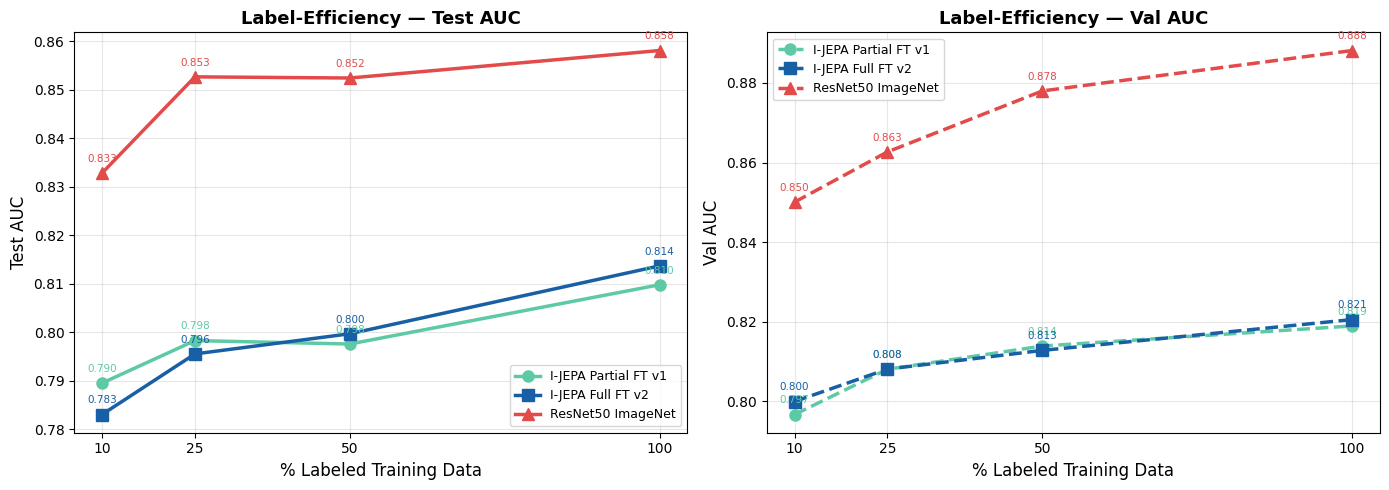

Saved: label_efficiency_chart.png


In [9]:
# ============================================================
# CELL 9: VẼ LABEL-EFFICIENCY CHART
# ============================================================
MODEL_COLORS = {
    "I-JEPA Partial FT v1": "#5DCAA5",
    "I-JEPA Full FT v2":    "#185FA5",
    "ResNet50 ImageNet":    "#E24B4A",
}
MODEL_MARKERS = {
    "I-JEPA Partial FT v1": "o",
    "I-JEPA Full FT v2":    "s",
    "ResNet50 ImageNet":    "^",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name in results_df["model"].unique():
    df_m  = results_df[results_df["model"]==model_name].sort_values("fraction")
    color  = MODEL_COLORS.get(model_name, "gray")
    marker = MODEL_MARKERS.get(model_name, "o")

    # Test AUC curve
    axes[0].plot(df_m["fraction"]*100, df_m["test_auc"],
                 marker=marker, color=color, lw=2.5, markersize=8,
                 label=model_name)
    axes[1].plot(df_m["fraction"]*100, df_m["val_auc"],
                 marker=marker, color=color, lw=2.5, markersize=8,
                 linestyle="--", label=model_name)

for ax, title, ylabel in zip(
    axes,
    ["Label-Efficiency — Test AUC", "Label-Efficiency — Val AUC"],
    ["Test AUC", "Val AUC"]
):
    ax.set_xlabel("% Labeled Training Data", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks([10, 25, 50, 100])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate points
    for model_name in results_df["model"].unique():
        df_m = results_df[results_df["model"]==model_name].sort_values("fraction")
        yvals = df_m["test_auc"] if ylabel == "Test AUC" else df_m["val_auc"]
        for x, y in zip(df_m["fraction"]*100, yvals):
            ax.annotate(f"{y:.3f}", (x, y),
                        textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=7.5,
                        color=MODEL_COLORS.get(model_name, "gray"))

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "label_efficiency_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: label_efficiency_chart.png")


In [10]:
# ============================================================
# CELL 10: PHÂN TÍCH GAP — I-JEPA vs ResNet50
# ============================================================
print("=== PHÂN TÍCH GAP: I-JEPA vs ResNet50 ===\n")

r50_df = results_df[results_df["model"]=="ResNet50 ImageNet"].set_index("fraction")

for ijepa_name in ["I-JEPA Partial FT v1", "I-JEPA Full FT v2"]:
    ijepa_df = results_df[results_df["model"]==ijepa_name].set_index("fraction")
    if len(ijepa_df) == 0:
        continue
    print(f"── {ijepa_name} vs ResNet50 ──")
    for frac in LABEL_FRACTIONS:
        if frac not in ijepa_df.index or frac not in r50_df.index:
            continue
        i_auc = ijepa_df.loc[frac, "test_auc"]
        r_auc = r50_df.loc[frac, "test_auc"]
        gap   = i_auc - r_auc
        print(f"  {int(frac*100):3d}%  I-JEPA={i_auc:.4f}  ResNet50={r_auc:.4f}  "
              f"gap={gap:+.4f}")
    print()

# Nhận xét tự động
print("── Nhận xét ──")
for ijepa_name in ["I-JEPA Partial FT v1", "I-JEPA Full FT v2"]:
    ijepa_df = results_df[results_df["model"]==ijepa_name].set_index("fraction")
    if len(ijepa_df) == 0:
        continue
    common = [f for f in LABEL_FRACTIONS if f in ijepa_df.index and f in r50_df.index]
    if len(common) < 2:
        continue
    gaps = [ijepa_df.loc[f, "test_auc"] - r50_df.loc[f, "test_auc"] for f in common]

    # FIX: cả 2 dòng phải cùng indent trong for loop
    gap_10  = gaps[common.index(0.10)] if 0.10 in common else gaps[0]
    gap_100 = gaps[common.index(1.00)] if 1.00 in common else gaps[-1]

    trend = gap_100 - gap_10
    print(f"{ijepa_name}:")
    print(f"  Gap tại 10%: {gap_10:+.4f} | Gap tại 100%: {gap_100:+.4f}")
    if trend > 0.005:
        print(f"  → Gap TĂNG khi có nhiều data (+{trend:.4f}) "
              f"— I-JEPA cải thiện chậm hơn ResNet50")
    elif trend < -0.005:
        print(f"  → Gap THU HẸP khi có nhiều data ({trend:.4f}) "
              f"— SSL lợi thế ở ít nhãn ✓")
    else:
        print(f"  → Gap ổn định ({trend:+.4f}) "
              f"— 2 model cải thiện với tốc độ tương đương")
    print()

elapsed = (time.time() - NOTEBOOK_START) / 3600
print(f"Tổng thời gian: {elapsed:.2f}h")

=== PHÂN TÍCH GAP: I-JEPA vs ResNet50 ===

── I-JEPA Partial FT v1 vs ResNet50 ──
   10%  I-JEPA=0.7895  ResNet50=0.8328  gap=-0.0433
   25%  I-JEPA=0.7983  ResNet50=0.8527  gap=-0.0544
   50%  I-JEPA=0.7976  ResNet50=0.8524  gap=-0.0548
  100%  I-JEPA=0.8098  ResNet50=0.8581  gap=-0.0483

── I-JEPA Full FT v2 vs ResNet50 ──
   10%  I-JEPA=0.7830  ResNet50=0.8328  gap=-0.0498
   25%  I-JEPA=0.7955  ResNet50=0.8527  gap=-0.0571
   50%  I-JEPA=0.7997  ResNet50=0.8524  gap=-0.0527
  100%  I-JEPA=0.8137  ResNet50=0.8581  gap=-0.0444

── Nhận xét ──
I-JEPA Partial FT v1:
  Gap tại 10%: -0.0433 | Gap tại 100%: -0.0483
  → Gap ổn định (-0.0050) — 2 model cải thiện với tốc độ tương đương

I-JEPA Full FT v2:
  Gap tại 10%: -0.0498 | Gap tại 100%: -0.0444
  → Gap TĂNG khi có nhiều data (+0.0054) — I-JEPA cải thiện chậm hơn ResNet50

Tổng thời gian: 6.50h


In [11]:
# ============================================================
# CELL 11: LƯU OUTPUT + NÉN ZIP
# ============================================================
print("Files trong output:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(OUTPUT_DIR)):50s}  ({p.stat().st_size/1e3:.1f} KB)")

shutil.make_archive("/kaggle/working/notebook07_label_efficiency", "zip", OUTPUT_DIR)
print("\nCreated: notebook07_label_efficiency.zip")
print(f"Tổng thời gian: {(time.time()-NOTEBOOK_START)/3600:.2f}h")


Files trong output:
  label_efficiency_chart.png                          (198.4 KB)
  label_efficiency_comparison.csv                     (0.4 KB)
  label_efficiency_pivot.csv                          (0.2 KB)
  label_efficiency_results.csv                        (0.6 KB)

Created: notebook07_label_efficiency.zip
Tổng thời gian: 6.50h
